# Wybór optymalnej aproksymacji — statystyczne miary błędu

Aby ocenić jakość aproksymacji, stosujemy miary statystyczne:

**Współczynnik determinacji $R^2$:**

$$R^2 = 1 - \frac{SS_{res}}{SS_{tot}} = 1 - \frac{\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}{\sum_{i=1}^{n}(y_i - \bar{y})^2}$$

gdzie $SS_{res}$ to suma kwadratów residuów, a $SS_{tot}$ to
całkowita suma kwadratów. Wartość $R^2$ bliska $1$ oznacza dobrą
jakość dopasowania.

**RMSE (Root Mean Square Error):**

$$RMSE = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}$$

Im mniejszy RMSE, tym lepsze dopasowanie.

W przeciwieństwie do MATLAB (gdzie używamy `cftool`), w Pythonie
obliczamy te miary ręcznie lub za pomocą `sklearn`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

N = 20
a, b = 1, 20
xx = np.linspace(a, b, N)

# fun1: x^6 * exp(-x) z 10% szumem
y1_clean = xx**6 * np.exp(-xx)
y1 = y1_clean * (1 + 2 * (np.random.rand(N) - 0.5) * 0.10)

# fun2: sin(x) * exp(-x)
y2 = np.sin(xx) * np.exp(-xx)

# fun3: |x|
y3 = np.abs(xx)

# fun4: wielomian stopnia 7
wsp_fun4 = np.array([3, 2, 1, 0, 1, 7, 5, 2])
y4 = np.polyval(wsp_fun4, xx)

print(f"Liczba punktów: {N}, przedział [{a}, {b}]")

Liczba punktów: 20, przedział [1, 20]


In [2]:
def fit_and_report(xx, yy, degree=3):
    wsp = np.polyfit(xx, yy, degree)
    yy_fit = np.polyval(wsp, xx)

    ss_res = np.sum((yy - yy_fit)**2)
    ss_tot = np.sum((yy - np.mean(yy))**2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 0
    rmse = np.sqrt(np.mean((yy - yy_fit)**2))

    print(f"Stopień: {degree}")
    print(f"R² = {r2:.6f}")
    print(f"RMSE = {rmse:.6e}")
    return wsp, r2, rmse

print("=" * 50)
print("Dane fun1 (x^6 · exp(-x) + szum)")
print("=" * 50)
for deg in [1, 2, 3, 5, 8]:
    fit_and_report(xx, y1, degree=deg)
    print()

Dane fun1 (x^6 · exp(-x) + szum)
Stopień: 1
R² = 0.303053
RMSE = 3.235681e+01

Stopień: 2
R² = 0.490112
RMSE = 2.767599e+01

Stopień: 3
R² = 0.897199
RMSE = 1.242697e+01

Stopień: 5
R² = 0.962548
RMSE = 7.500777e+00

Stopień: 8
R² = 0.996685
RMSE = 2.231461e+00



Stopień: 5
R² = 0.962548
RMSE = 7.500777e+00


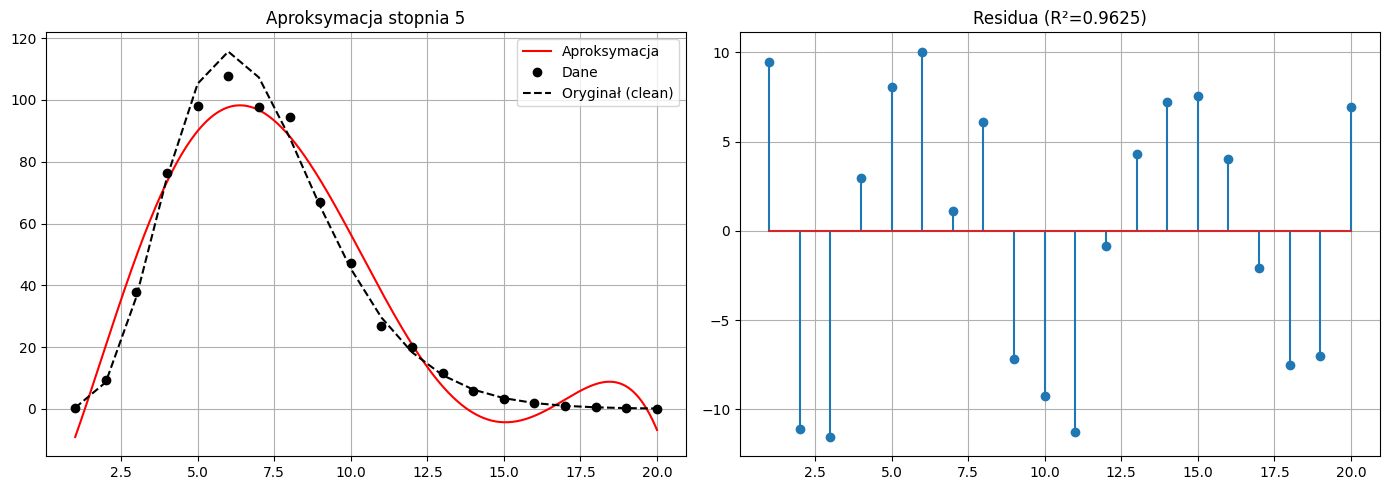

In [3]:
deg = 5
wsp, r2, rmse = fit_and_report(xx, y1, degree=deg)

x_fine = np.linspace(a, b, 400)
y_fine = np.polyval(wsp, x_fine)
residuals = y1 - np.polyval(wsp, xx)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
ax.plot(x_fine, y_fine, 'r-', label='Aproksymacja')
ax.plot(xx, y1, 'ko', label='Dane')
ax.plot(xx, xx**6*np.exp(-xx), 'k--', label='Oryginał (clean)')
ax.set_title(f"Aproksymacja stopnia {deg}")
ax.legend()
ax.grid(True)

ax = axes[1]
ax.stem(xx, residuals)
ax.set_title(f"Residua (R²={r2:.4f})")
ax.grid(True)
plt.tight_layout()
plt.show()

In [4]:
# Test na pozostałych funkcjach
funcs = {
    "fun2: sin(x)·exp(-x)": y2,
    "fun3: |x|": y3,
    "fun4: wielomian stopnia 7": y4,
}

for name, yy in funcs.items():
    print("=" * 50)
    print(f"Dane: {name}")
    print("=" * 50)
    for deg in [1, 2, 3, 5, 7, 8]:
        fit_and_report(xx, yy, degree=deg)
    print()

Dane: fun2: sin(x)·exp(-x)
Stopień: 1
R² = 0.224824
RMSE = 6.301562e-02
Stopień: 2
R² = 0.505977
RMSE = 5.030624e-02
Stopień: 3
R² = 0.752522
RMSE = 3.560547e-02
Stopień: 5
R² = 0.978347
RMSE = 1.053198e-02
Stopień: 7
R² = 0.995560
RMSE = 4.769223e-03
Stopień: 8
R² = 0.996411
RMSE = 4.287520e-03

Dane: fun3: |x|
Stopień: 1
R² = 1.000000
RMSE = 5.798086e-15
Stopień: 2
R² = 1.000000
RMSE = 1.409590e-15
Stopień: 3
R² = 1.000000
RMSE = 5.394816e-15
Stopień: 5
R² = 1.000000
RMSE = 6.081803e-15
Stopień: 7
R² = 1.000000
RMSE = 5.000751e-15
Stopień: 8
R² = 1.000000
RMSE = 6.723452e-15

Dane: fun4: wielomian stopnia 7
Stopień: 1
R² = 0.572015
RMSE = 6.959180e+08
Stopień: 2
R² = 0.899840
RMSE = 3.366598e+08
Stopień: 3
R² = 0.988004
RMSE = 1.165077e+08
Stopień: 5
R² = 0.999987
RMSE = 3.808110e+06
Stopień: 7
R² = 1.000000
RMSE = 7.089945e-07
Stopień: 8
R² = 1.000000
RMSE = 1.236387e-06



## Porównanie i wnioski

| Funkcja | Najlepszy stopień | Uzasadnienie |
|---|---|---|
| fun1 (x^6·e⁻ˣ + szum) | 5-8 | Zaokrąglenie + szum maskują wyższe składowe |
| fun2 (sin(x)·e⁻ˣ) | 8+ | Funkcja transcendentalna, potrzeba więcej wyrazów |
| fun3 (|x|) | 1 | Przedział $[1, 20]$ nie zawiera $x=0$, więc $|x|=x$ jest tam dokładnie liniowe (już przy stopniu 1: $R^2=1{,}000000$) |
| fun4 (wielomian stopnia 7) | 7 | Dokładnie dopasowuje wielomian źródłowy |

**Wskazówki do oceny:**
- Dla danych z szumem, wysoki stopień prowadzi do overfitting
- Dla czystych danych, stopień powinien odpowiadać złożoności funkcji
- $R^2 > 0.99$ to dobry próg jakości

## Ćwiczenie 1

Zmień przedział $[a, b]$ (np. $[1, 10]$, $[5, 20]$, $[0, 50]$) i zaobserwuj:
- Jak zmienia się współczynnik $R^2$ dla danego stopnia?
- Czy optymalny stopień zależy od przedziału?

### Szybkodostęp
| Skróty | Działanie |
|---|---|
| `Ctrl+Enter` | Uruchom komórkę |
| `Shift+Enter` | Uruchom i przejdź dalej |
| `Shift+Tab` | Tooltip |
| `Alt+Enter` | Uruchom i wstaw nową |